<h1>Import Libraries</h1>


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

<h1>Load Dataset</h1>

In [2]:
df = pd.read_csv("../dataset/medical_insurance.csv")
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<h1>Initial Data Inspection</h1>

In [3]:
print("Dataset Shape:", df.shape)
df.info()

# Display descriptive statistics
df.describe()

Dataset Shape: (2772, 7)
<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 151.7 KB


,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


<h1> Data Quality Checking</h1>


In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
print("\nNumber of Duplicate Rows:", df.duplicated().sum())


Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Number of Duplicate Rows: 1435


<h1>Remove Duplicates</h1>

In [5]:
df = df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (1337, 7)


<h1> Exploratory Data Analysis (EDA)</h1>

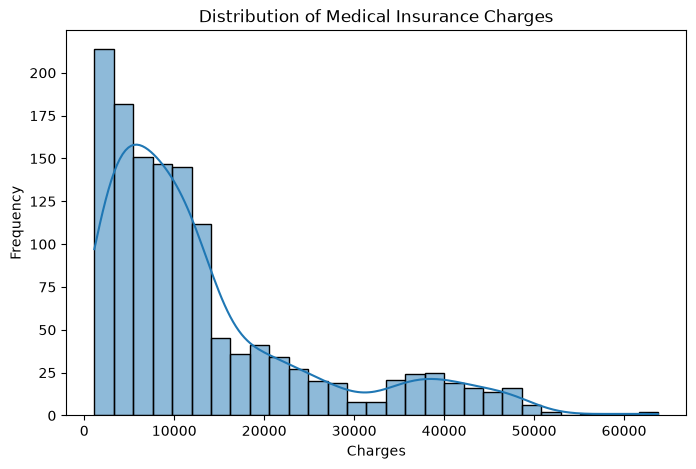

In [6]:
# ------------------------------------------------------------
# 6.1 Distribution of Medical Insurance Charges
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    df["charges"],
    kde=True
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

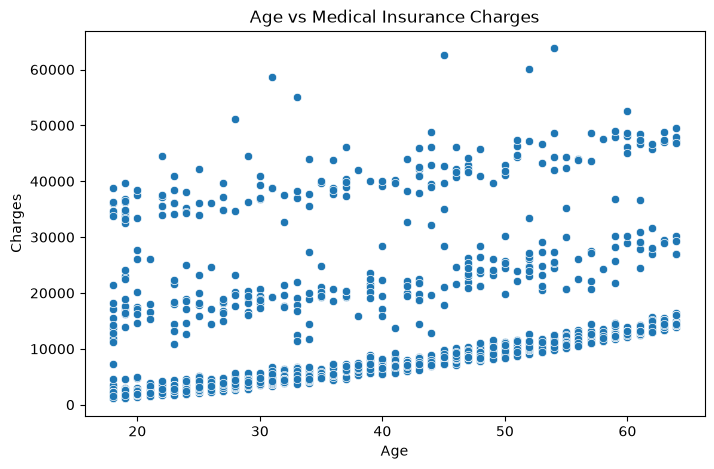

In [7]:
# ------------------------------------------------------------
# 6.2 Age vs Medical Insurance Charges
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges"
)

plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

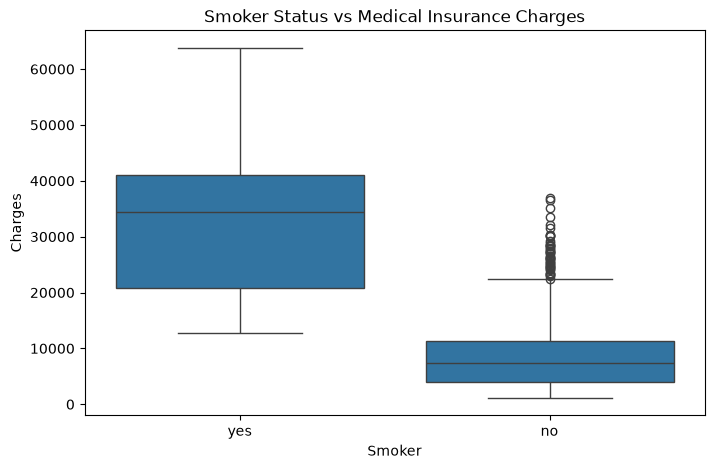

In [8]:
# ------------------------------------------------------------
# 6.3 Smoker Status vs Medical Insurance Charges
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Smoker Status vs Medical Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

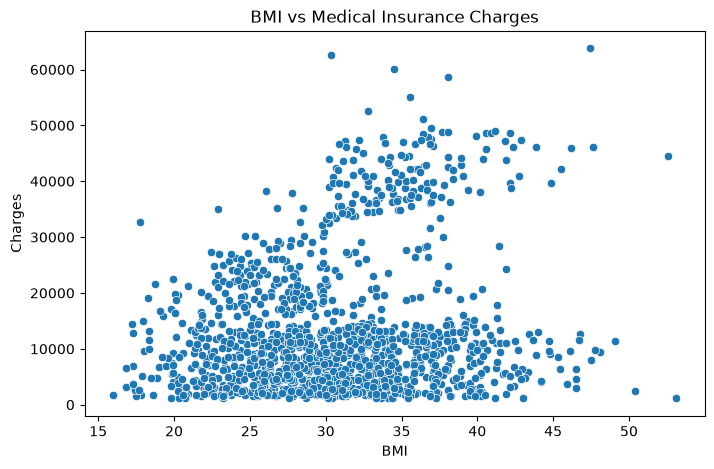

In [9]:
# ------------------------------------------------------------
# 6.4 BMI vs Medical Insurance Charges
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

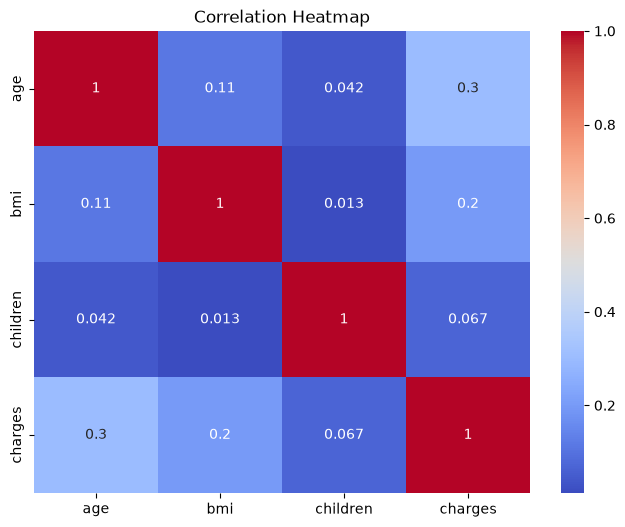

In [10]:
# ------------------------------------------------------------
# 6.5 Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

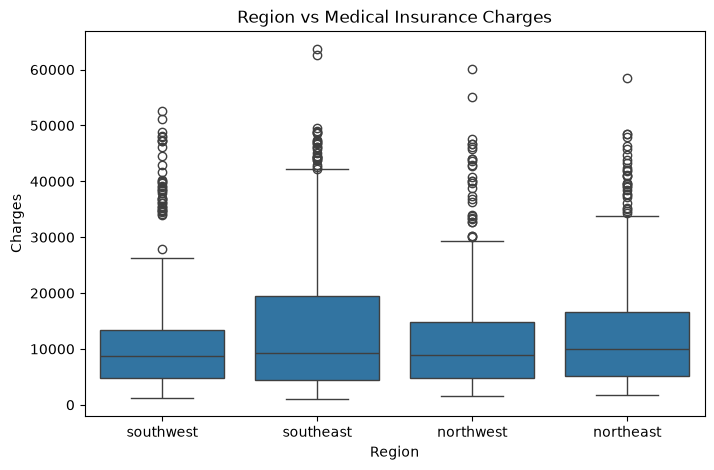

In [11]:
# ------------------------------------------------------------
# 6.6 Region vs Medical Insurance Charges
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Region vs Medical Insurance Charges")
plt.xlabel("Region")
plt.ylabel("Charges")

plt.show()

<h1>Feature Engineering</h1>

In [12]:
smoker_flag = (df["smoker"] == "yes").astype(int)
df["smoker_bmi"] = smoker_flag * df["bmi"]
df["age_squared"] = df["age"] ** 2
df["age_smoker"] = df["age"] * smoker_flag

df["is_underweight"] = (df["bmi"] < 18.5).astype(int) 
df["is_obese"] = (df["bmi"] >= 30).astype(int) 
df["obese_smoker"] = df["is_obese"] * smoker_flag 
df["children_smoker"] = df["children"] * smoker_flag 

<h1>Separate Features and Target</h1>

In [13]:
# Features (input variables)
X = df.drop("charges", axis=1)

# Target variable (medical insurance cost)
y = df["charges"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,age,sex,bmi,children,smoker,region,smoker_bmi,age_squared,age_smoker,is_underweight,is_obese,obese_smoker,children_smoker
0,19,female,27.900,0,yes,southwest,27.9,361,19,0,0,0,0
1,18,male,33.770,1,no,southeast,0.0,324,0,0,1,0,0
2,28,male,33.000,3,no,southeast,0.0,784,0,0,1,0,0
3,33,male,22.705,0,no,northwest,0.0,1089,0,0,0,0,0
4,32,male,28.880,0,no,northwest,0.0,1024,0,0,0,0,0



Target:


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

<h1>Encode Categorical Variables</h1>

In [14]:
# Categorical features
categorical_features = [
    "sex",
    "smoker",
    "region"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Apply encoding
X_encoded = preprocessor.fit_transform(X)

# Convert encoded data into a DataFrame
X_encoded = pd.DataFrame(
    X_encoded,
    columns=preprocessor.get_feature_names_out()
)

# Display encoded features
X_encoded.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__smoker_bmi,remainder__age_squared,remainder__age_smoker,remainder__is_underweight,remainder__is_obese,remainder__obese_smoker,remainder__children_smoker
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,27.9,361.0,19.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,0.0,324.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,0.0,784.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,0.0,1089.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,0.0,1024.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# Combine encoded features with the target variable
df_encoded = pd.concat(
    [
        X_encoded,
        y.reset_index(drop=True)
    ],
    axis=1
)

# Display final dataset
df_encoded.head()

print("Final Dataset Shape:", df_encoded.shape)

Final Dataset Shape: (1337, 16)


<h1>Correlation Analysis after Encoding</h1>

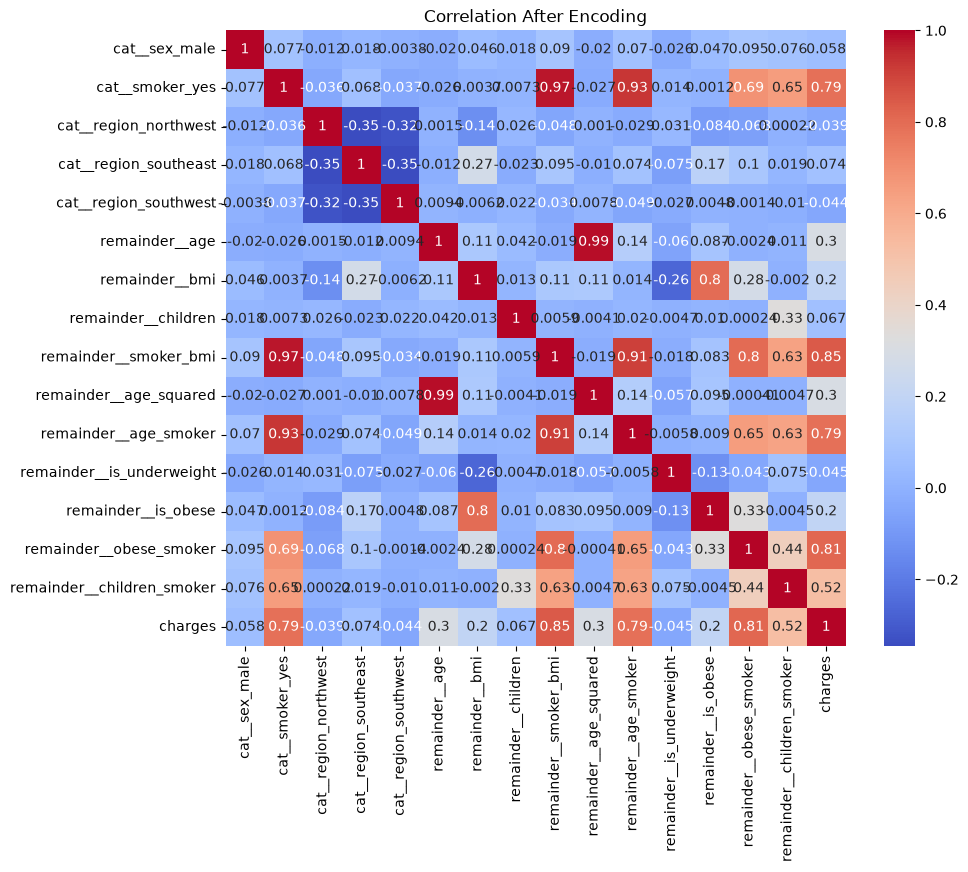

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation After Encoding")

plt.show()

<h1>Save Processed Dataset</h1>

In [17]:
df_encoded.to_csv(
    "../dataset/medical_insurance_encoded.csv",
    index=False
)